# Forecasting I
# Baseline Methods

This workbook is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20I%20-%20Baseline%20Methods.ipynb">Forecasting I - Baseline Methods</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20II%20-%20Exponential%20Smoothing.ipynb">Forecasting II - Exponential Smoothing</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20III%20-%20Autoregressive%20Models.ipynb">Forecasting III - Autoregressive Models</a>

Forecasting is tricky work, and sometimes quite complicated models perform little better than baseline heuristics.

<p><i>"Good forecasts capture the genuine pattterns and relationship that exist in historical data, but do not replicate past events that will not occur again."</i></p>
- Forecasting: Principles and Practice, Rob J Hyndman and George Athanasopoulos

# Pulling Financial Data

We'll select two datasets from the US Federal Reserve Economic Database; one seasonal and one non-seasonal. For a list of data available from FRED through NasdaqLink, see: https://data.nasdaq.com/data/FRED-federal-reserve-economic-data

First, we install the nasdaqdatalink package if it is not installed already.

In [1]:
# !pip install --user Nasdaq-Data-Link

Then, import the necessary module.

In [2]:
import nasdaqdatalink

To make more than 50 calls to the database per day requires an API key, generated upon free sign-up at: https://data.nasdaq.com/sign-up. You can save it to the api_key variable to use it, as below.

In [3]:
nasdaqdatalink.ApiConfig.api_key = "4xJoCvA6Ws7KXkQVw9ip"

## Consumer Price Index Data

This represents the index of a weighted average market basket of consumer goods and services compared to the pricing of a reference year, and captured on an annual basis.

In [4]:
cpi = nasdaqdatalink.get("FRED/FPCPITOTLZGUSA", start_date="1965-01-01")
cpi.head()

,Value
Date,
1965-01-01,1.585169
1966-01-01,3.015075
1967-01-01,2.772786
1968-01-01,4.271796
1969-01-01,5.462386


## Seasonal Borrowing Data

The Federal Reserve's seasonal credit program is designed to assist small depository institutions in managing significant seasonal swings in their loans and deposits. Seasonal credit is available to depository institutions that can demonstrate a clear pattern of recurring intra-yearly swings in funding needs. Eligible institutions are usually located in agricultural or tourist areas.

In [5]:
sborrow = nasdaqdatalink.get("FRED/SEABORRW", start_date="1990-01-01")
sborrow.head()

,Value
Date,
1990-01-03,58.0
1990-01-10,58.0
1990-01-17,41.0
1990-01-24,41.0
1990-01-31,44.0


Notice that this data is captured on a weekly level, though with consecutively identical values for each pair of weeks. It should still suit our purposes, however.

# Exploratory Data Analysis

We'll import the other modules we will be using throughout this workbook, and then visualize the data.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
import statsmodels.api as sm
import scipy

### CPI Data

First, a look at the time-series trend for the CPI data.

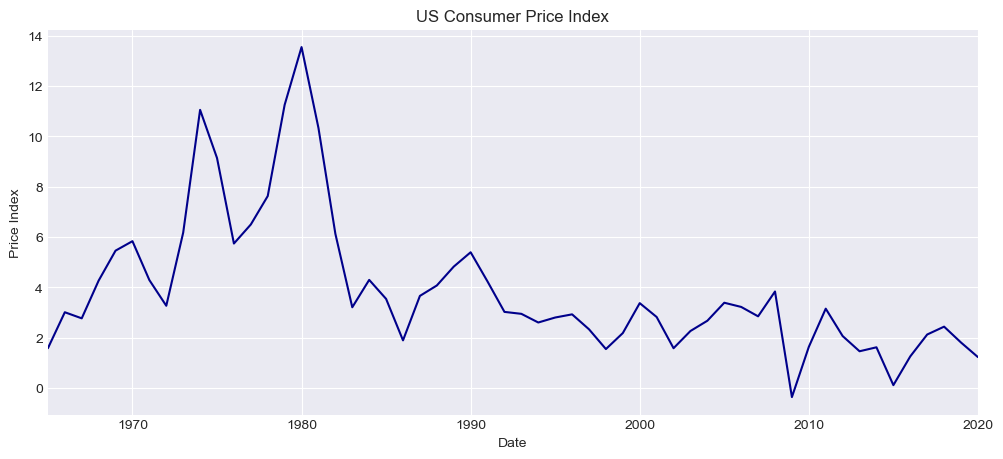

In [7]:
cpi['Value'].plot(figsize=(12,5), 
         title="US Consumer Price Index", 
         xlabel='Date',
         ylabel="Price Index",
         color='darkblue');

There is a value dipping below 0, which I'll assume reflects a bad data point, and snip out of the dataset.

In [8]:
cpi = cpi[cpi['Value'] > 0]

Next, a histogram of the CPI data.

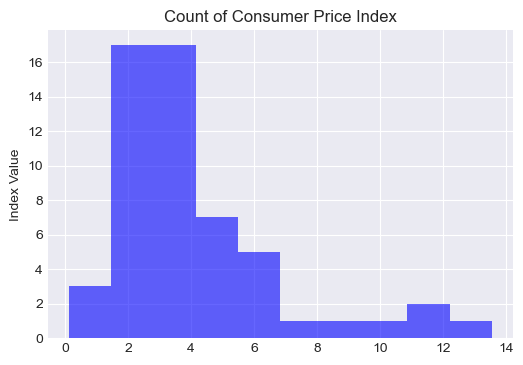

In [9]:
fig = plt.figure(figsize=(6,4))

ax1 = plt.subplot(111)
ax1.hist(cpi['Value'], color='blue', alpha=0.6)
plt.ylabel('Index Value')
ax1.set_title('Count of Consumer Price Index')
plt.show()

## Stationarity

A stationary time series is one where statistical properties such as mean, variance, and autocorrelation do not change significantly over over time. Time series' which do not meet the criterion of stationarity can be made more stationary through differencing and/or transforms. It is common to take the first difference, the second difference, or to apply the Box-Cox transform or another transformation, before perform the forecasting operation using transformed data, and then reverting the predictions to the original scale. Checks for stationarity include plots, statistics, and statistical tests.

## Autocorrelation

Autocorrelation measures the correlation between lagged values of a time series. The autocorrelation function (ACF) measures how the correlation changes between two values as the lag is increased, and auto-correlation coefficients outside of the confidence bound around zero can be considered indicative of remaining pattern for the model to fit to.
However, some autocorrelation coefficients will likely poke through the confidence boundary just by chance, at a rate depending on the significance level.

Below is an autocorrelation plot of the CPI data.

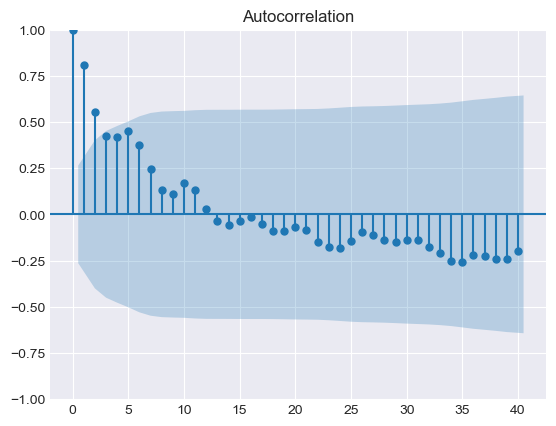

In [10]:
sm.graphics.tsa.plot_acf(cpi['Value'], lags=40)
plt.show();

The coefficient at point 0 will always be 1.0. Given that the coefficients quickly proceed to stay within the confidence bounds around zero, autocorrelation is not a heavy concern for this dataset.

### Seasonal Borrowing Data

Next, we'll run a time-series trend and histogram on the seasonal borrowing data.

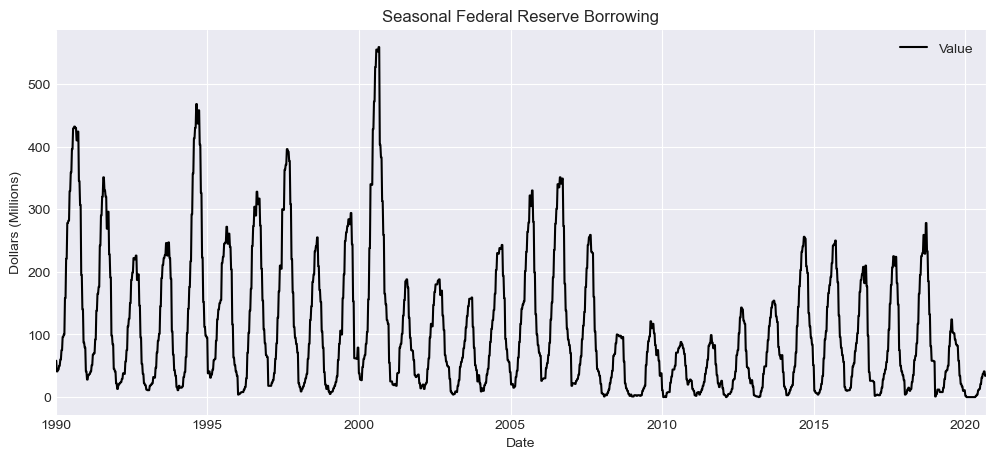

In [11]:
sborrow.plot(figsize=(12,5), 
         title="Seasonal Federal Reserve Borrowing", 
         xlabel="Date", 
         ylabel="Dollars (Millions)",
         color='black');

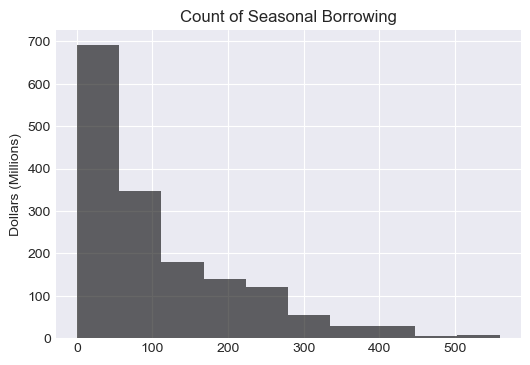

In [12]:
fig = plt.figure(figsize=(6,4))

ax2 = plt.subplot(111)
ax2.hist(sborrow['Value'], color='black', alpha=0.6)
plt.ylabel('Dollars (Millions)')
ax2.set_title('Count of Seasonal Borrowing')
plt.show()

Then, an autocorrelation plot.

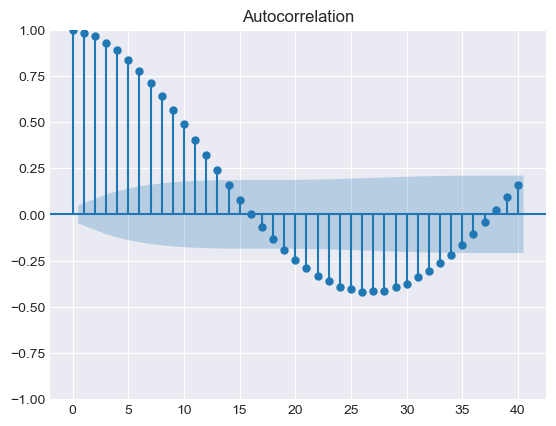

In [13]:
sm.graphics.tsa.plot_acf(sborrow['Value'], lags=40)
plt.show();

Because the data is seasonal, it shows a high level of auto-correlation. This can be mitigated with differencing or transforms, or using models which expect seasonality.

# Decomposition

One can analyze seasonality by breaking a time-series down into systematic and non-systematic components. Systematic components have consistency or recurrence, and non-systematic components cannot be modeled.

The systematic components include:
1. Level: the average value of the dataset
2. Trend: the magnitude of the slope
3. Seasonality: the repeating cycle

The fourth component, which is non-systematic, is noise.

### Additive and Multiplicative Decomposition

There are additive and multiplicative versions of decomposition. The additive method is appropriate if the magnitude of the seasonal fluctuations do not vary with the level of the time series. In cases where the magnitude of seasonality increases or decreases with the trend, the multiplicative method can be more appropriate.

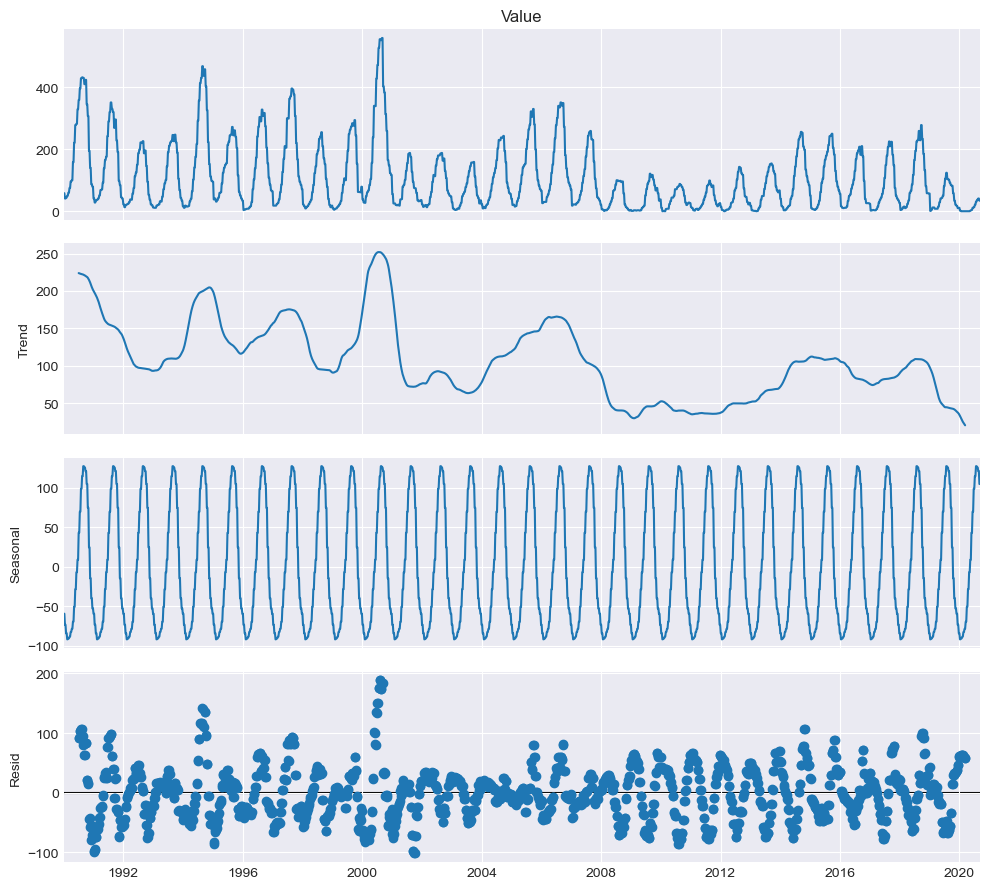

In [14]:
adj_sborrow = sborrow
adj_sborrow['Value'] = adj_sborrow['Value'] + 0.0001
filt_sborrow = adj_sborrow[sborrow.index.year > 2008]

decomp = sm.tsa.seasonal_decompose(adj_sborrow['Value'], model='additive')
fig = decomp.plot()
fig.set_size_inches((10,9))
fig.tight_layout()
plt.show()

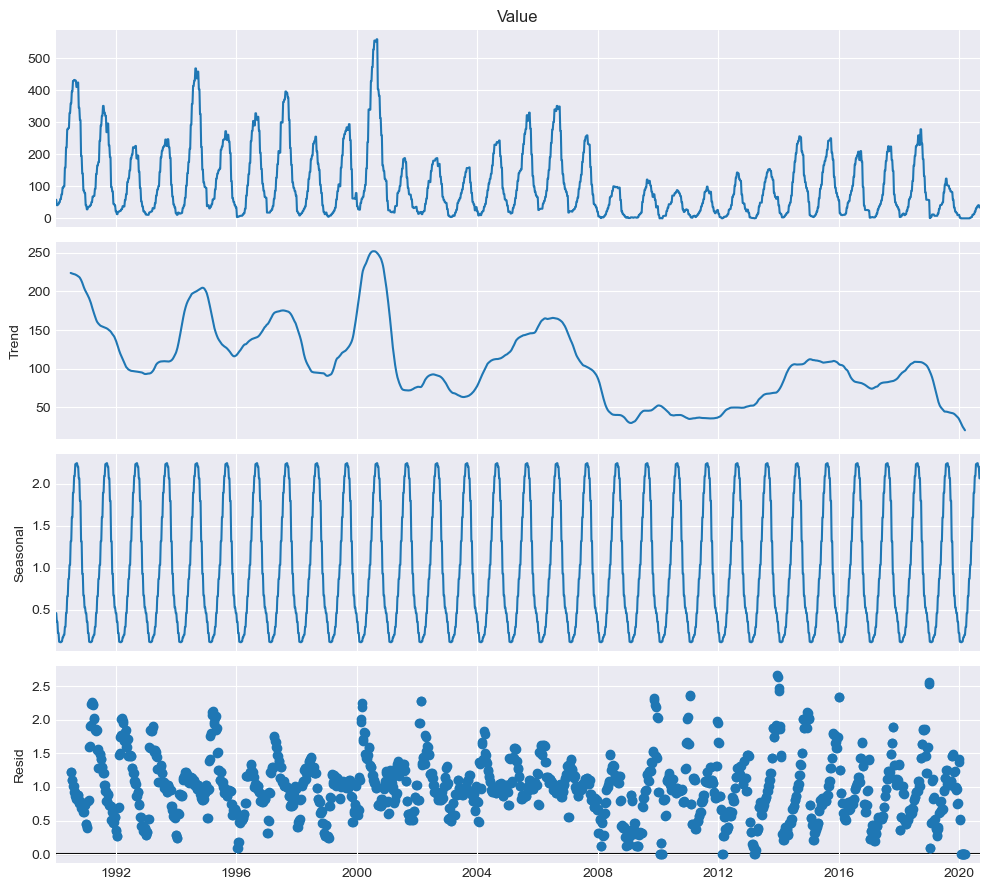

In [15]:
adj_sborrow = sborrow
adj_sborrow['Value'] = adj_sborrow['Value'] + 0.0001
filt_sborrow = adj_sborrow[sborrow.index.year > 2008]

decomp = sm.tsa.seasonal_decompose(adj_sborrow['Value'], model='multiplicative')
fig = decomp.plot()
fig.set_size_inches((10,9))
fig.tight_layout()
plt.show()

# Transformations and Adjustments

Commonly required adjustments include calendar-related adjustments, population or inflation-related adjustments, or mathematical transformations, such as a logarithmic or Box-Cox transformation.

Firstly, we have some years in the seasonal borrowing data that have 53 weeks and some weeks that have 52. For consistency, I will trim them all down to 52.

In [16]:
sborrow = sborrow[sborrow.index.weekofyear < 53]

## Box-Cox Transformation

The Box-Cox transformation is a power transformation that makes a series of data more normally distributed, which is a state assumed by many models.

$$w_t  =
\begin{cases}
  \log(y_t) & \text{if $\lambda=0$};  \\
  (y_t^\lambda-1)/\lambda & \text{otherwise}.
\end{cases}$$

The below illustrates, first using the CPI data. If we do not specify the lambda parameter, scipy will find and return an optimal value.

In [17]:
cpi['bc_cpi'], max_log = scipy.stats.boxcox(cpi['Value'])
print('lambda =', max_log)

lambda = 0.28092002061758786


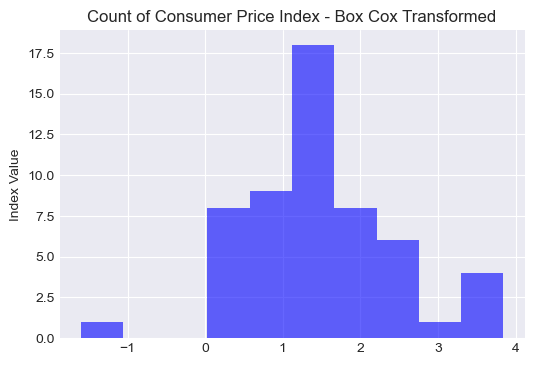

In [18]:
fig = plt.figure(figsize=(6,4))

ax1 = plt.subplot(111)
ax1.hist(cpi['bc_cpi'], color='blue', alpha=0.6)
plt.ylabel('Index Value')
ax1.set_title('Count of Consumer Price Index - Box Cox Transformed')
plt.show()

And for the seasonal borrowing data, which we also know has a skewed distribution:

In [89]:
sborrow['bc_sborrow'], max_log = scipy.stats.boxcox(sborrow['Value'] + 0.0001)
print('lambda =',max_log)

lambda = 0.297935807696509


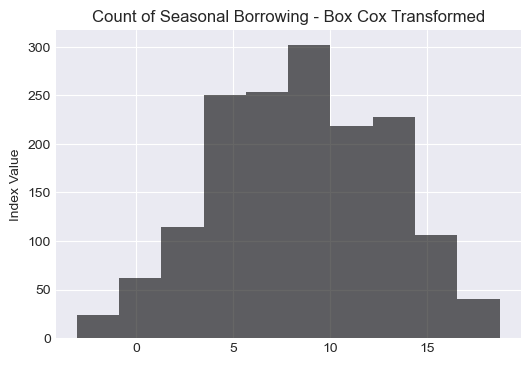

In [20]:
fig = plt.figure(figsize=(6,4))

ax1 = plt.subplot(111)
ax1.hist(sborrow['bc_sborrow'], color='black', alpha=0.6)
plt.ylabel('Index Value')
ax1.set_title('Count of Seasonal Borrowing - Box Cox Transformed')
plt.show()

The transform can be easily reversed, as one would require to get the predictions. Below demonstrates using the CPI data.

In [21]:
def invboxcox(y,ld):
    if ld == 0:
        return(np.exp(y))
    else:
        return(np.exp(np.log(ld*y+1)/ld))

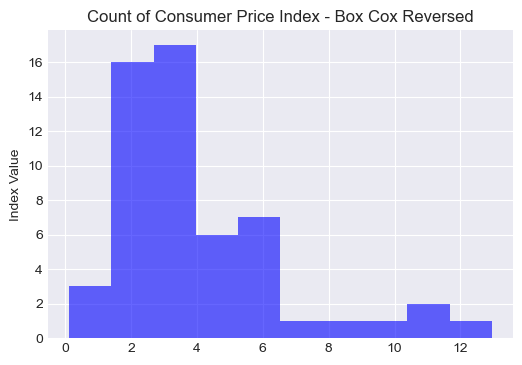

In [22]:
inversion = invboxcox(cpi['bc_cpi'],max_log)

fig = plt.figure(figsize=(6,4))
ax1 = plt.subplot(111)
ax1.hist(inversion, color='blue', alpha=0.6)
plt.ylabel('Index Value')
ax1.set_title('Count of Consumer Price Index - Box Cox Reversed')
plt.show()

# Validation

Preferred to a simple train/test split for time-series analysis is a technique called walk-forward validation. However, I will dive into that in the next workbook, and treat these baseline methods more simply, settling for a train/test split that respects the temporal order.

In [23]:
def train_test_split(data, n_test):
    return data[:-n_test], data[-n_test:]

In [24]:
cpi_train, cpi_test = train_test_split(cpi['Value'].values, 10)
sborrow_train, sborrow_test = train_test_split(sborrow['Value'].values, 80)

# Error Metrics

There are a variety of methods by which we can compare predicted values to actuals.

### $R^2$

$R^2$ is the percentage of variance explained by the model, however it is biased toward inclusion of a larger set of model parameters

$$R^2 = \frac{\sum(\hat{y}_{t} - \bar{y})^2}{\sum(y_{t}-\bar{y})^2}$$

### Adjusted $R^2$

Adjusted $R^2$, like the AIC and BIC, will penalize a model in accordance with its number of parameters, in order to make for fairer comparisons among different models.

$$\bar{R}^2 = 1-(1-R^2)\frac{T-1}{T-k-1}$$

### Mean Squared Error (MSE)

MSE is a commonly used and understood metric that places a greater penalty on larger errors.

$$MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y})^2$$

### Root Mean Squared Error (RMSE)

By taking the square root of MSE, units are put back into their original scale

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y})^2}$$

$$RMSE = \sqrt{MSE}$$

### Mean (or Median) Absolute Error

The average of the absolute values of deviation from the average tends to be well-interpreted by laypersons.

$$\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)$$

### Mean Absolute Percentage Error (MAPE)

Mean absolute percentage error has the advantage of being scale-invariant, however, percentage-based metrics can fail or blow up if values include or come close to zero.

$$\frac{1}{n} \sum_{i=1}^n \frac{y_i - \hat{y}_i}{y_i} \times 100$$

A couple more metrics, the AIC and BIC, will be discussed when we get to ARIMA models.

For now, we will use RMSE and MAE as our measures of predictive success.

In [25]:
from sklearn.metrics import mean_absolute_error

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

In [26]:
def evaluate_forecast(actuals, predictions, cht_title=''):
    rmse_result = rmse(actuals, predictions)
    mae_result = mean_absolute_error(actuals, predictions)

    print('RMSE: %.2f' % rmse_result)
    print('MAE: %.2f' % mae_result)

    plt.figure(figsize=(12,5))
    plt.plot(actuals, label='actual')
    plt.plot(predictions, 'darkred', label='predicted')
    plt.title(cht_title)
    plt.ylabel('Value')
    plt.legend()
    plt.show();
    
    return rmse_result, mae_result

We'll also create a dataframe to track results, and a function to update it.

In [58]:
results_df = pd.DataFrame(columns = ('Dataset', 'Model', 'Application', 'RMSE', 'MAE'))

def append_results(dataset, model, application, results):
    new_rownum = len(results_df) + 1
    results_df.loc[new_rownum,'Dataset'] = dataset
    results_df.loc[new_rownum,'Model'] = model
    results_df.loc[new_rownum,'Application'] = application
    results_df.loc[new_rownum,'RMSE'] = round(results[0],2)
    results_df.loc[new_rownum,'MAE'] = round(results[1],2)

# Baseline Forecasting Methods

A common mistake that people make is failure to compare more complicated methods against a simple baseline model. A baseline model is a simple, fast, and repeatable solution that uses heuristics or simple statistics to compute a forecast, and should not require model fitting and be easy to implement.

## The Naive Forecast

The naive forecast simply expects each time point to be equal to the previous time point, and is an appropriate choice when the data is completely random.

In [59]:
def naive_forecast(train, test):
    history = [x for x in train]
    predictions = list()
    for i in range(len(test)):
        yhat = history[-1]
        predictions.append(yhat)
        history.append(test[i])
    return predictions

#### CPI Data, Single-Step Naive Forecast

RMSE: 0.95
MAE: 0.84


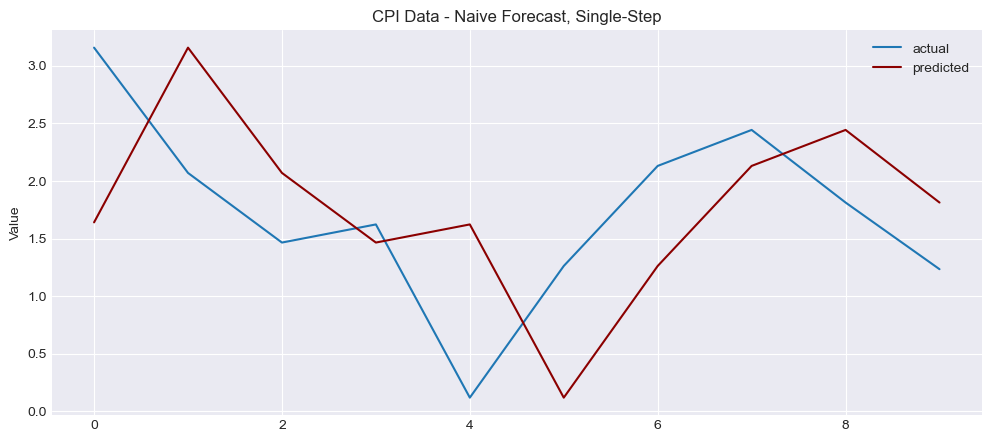

In [60]:
predictions = naive_forecast(cpi_train,cpi_test)
results = evaluate_forecast(cpi_test,predictions, "CPI Data - Naive Forecast, Single-Step")
append_results('CPI','Naive','Single-Step', results)

#### CPI Data, Multi-Step Naive Forecast

RMSE: 0.78
MAE: 0.59


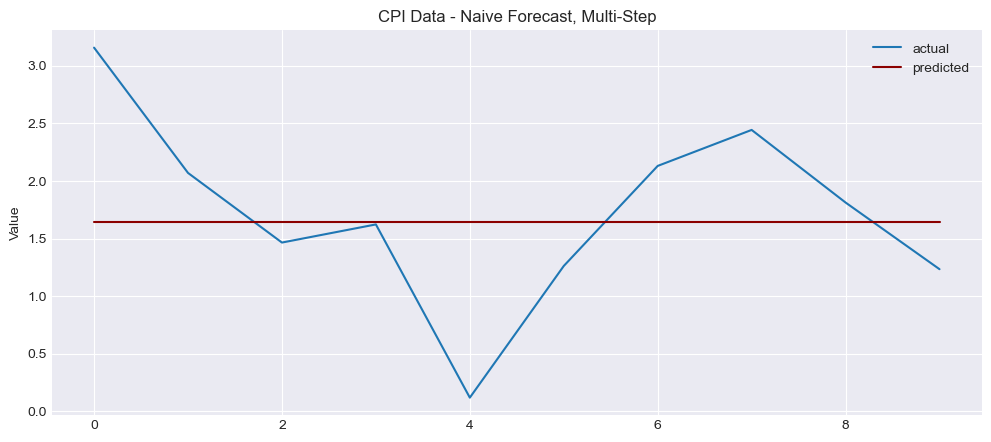

In [61]:
for x in range(len(predictions)):
    predictions[x] = predictions[0]
predictions[:5]

results = evaluate_forecast(cpi_test,predictions, "CPI Data - Naive Forecast, Multi-Step")
append_results('CPI','Naive','MultiStep', results)

In [62]:
results_df

,Dataset,Model,Application,RMSE,MAE
1,CPI,Naive,Single-Step,0.95,0.84
2,CPI,Naive,MultiStep,0.78,0.59


The naive forecast is found to be not great on a single-step basis, because of the jagged trend, however it happens to perform well on the test set as a multi-step forecast (given the particular data and test set chosen) for the same reason.

### Seasonal Borrowing Data, Single Step Naive Forecast

RMSE: 7.72
MAE: 3.67


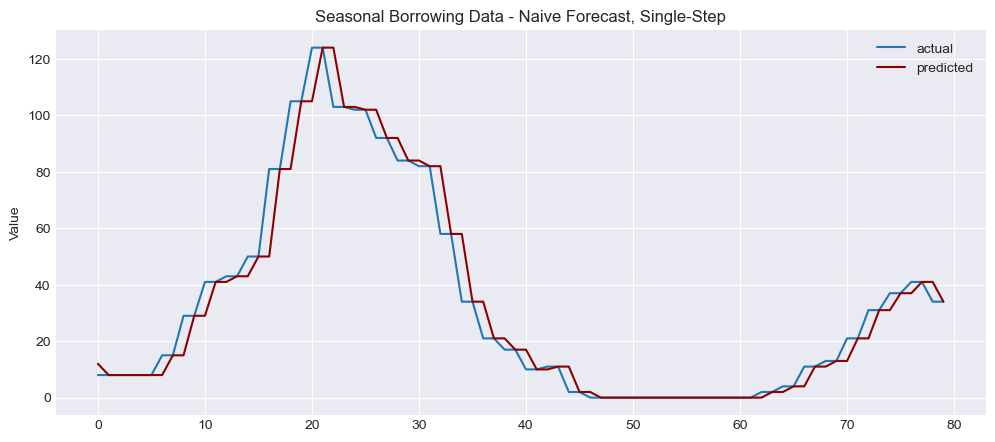

In [63]:
predictions = naive_forecast(sborrow_train,sborrow_test)
results = evaluate_forecast(sborrow_test,predictions, "Seasonal Borrowing Data - Naive Forecast, Single-Step")
append_results('SBorrow','Naive','Single-Step', results)

The predictions and actuals may appear similar, as each prediction point is only 1 step horizontally from being equal to the last, and the high degree of variability helps to conceal the amount of vertical difference between the predictions and the actuals, but we will find models that more precisely fit this data, given its strong seasonality.

### Seasonal Borrowing Data, Multi-step Naive Forecast

Of course, the naive forecast, which will copy the last known value for each step in a multi-step forecast, will not be appropriate for this data, given the seasonality.

In [64]:
for x in range(len(predictions)):
    predictions[x] = predictions[0]
predictions[:5]

[12.0002, 12.0002, 12.0002, 12.0002, 12.0002]

RMSE: 41.51
MAE: 28.05


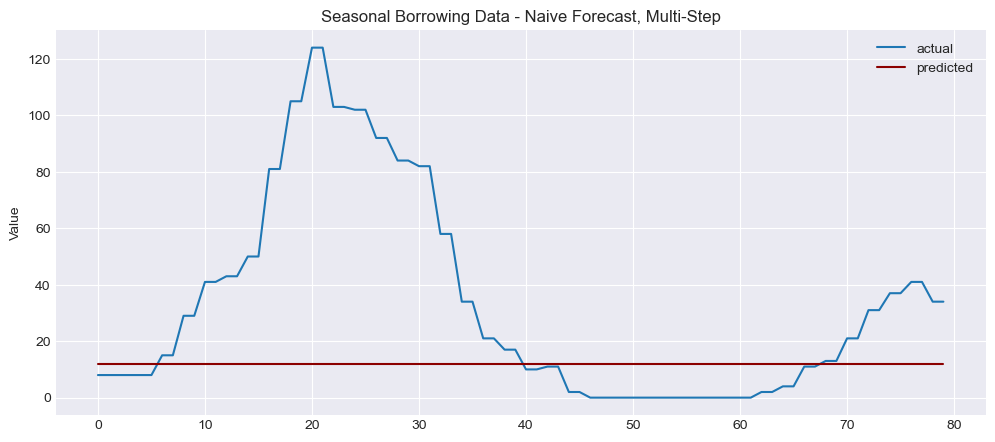

In [65]:
results = evaluate_forecast(sborrow_test,predictions, "Seasonal Borrowing Data - Naive Forecast, Multi-Step")
append_results('SBorrow','Naive','Multi-Step', results)

#### Seasonal Borrowing Data, Single-Step Naive Seasonal Forecast

We can create a seasonal naive forecast, where each value is expected to equal that of the same time period one cycle ago (last year).

In [66]:
def naive_seasonal(train, test):
    history = [x for x in train]
    predictions = list()
    for i in range(len(test)):
        yhat = history[-52]
        predictions.append(yhat)
        history.append(test[i])
    return predictions

RMSE: 75.37
MAE: 57.85


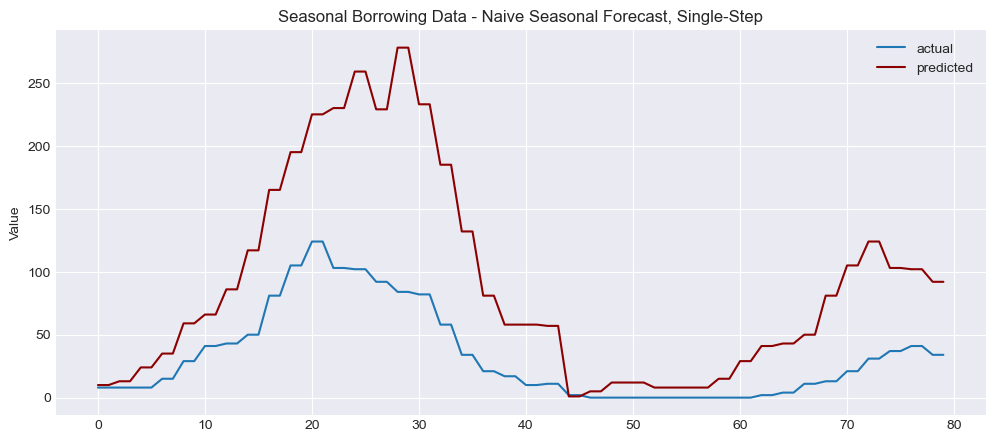

In [67]:
predictions = naive_seasonal(sborrow_train,sborrow_test)
results = evaluate_forecast(sborrow_test,predictions, "Seasonal Borrowing Data - Naive Seasonal Forecast, Single-Step")
append_results('SBorrow','Naive Seasonal','Multi-Step', results)

The results are not particularly good on this data and test set.

## Moving Average

#### CPI Data, Single-Step Training Set

In [68]:
cpi_train_copy = pd.DataFrame(cpi_train)
cpi_train_copy['MA-3'] = cpi_train_copy[0].rolling(3).mean().shift(1)
cpi_train_copy = cpi_train_copy.dropna()

RMSE: 2.36
MAE: 1.69


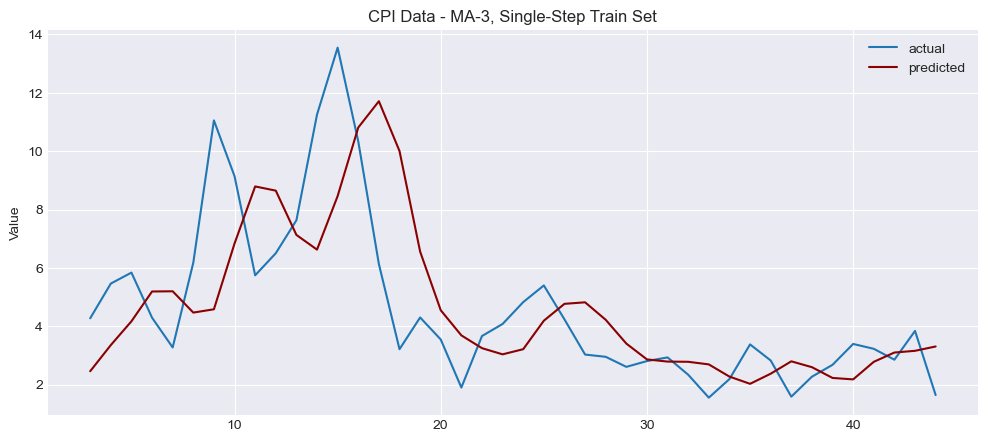

In [69]:
results = evaluate_forecast(cpi_train_copy[0], cpi_train_copy['MA-3'], 'CPI Data - MA-3, Single-Step Train Set')
append_results('CPI','MA-3','Single-Step Train Set', results)

#### CPI Data, Single Step Moving Average (MA-3)

RMSE: 0.98
MAE: 0.83


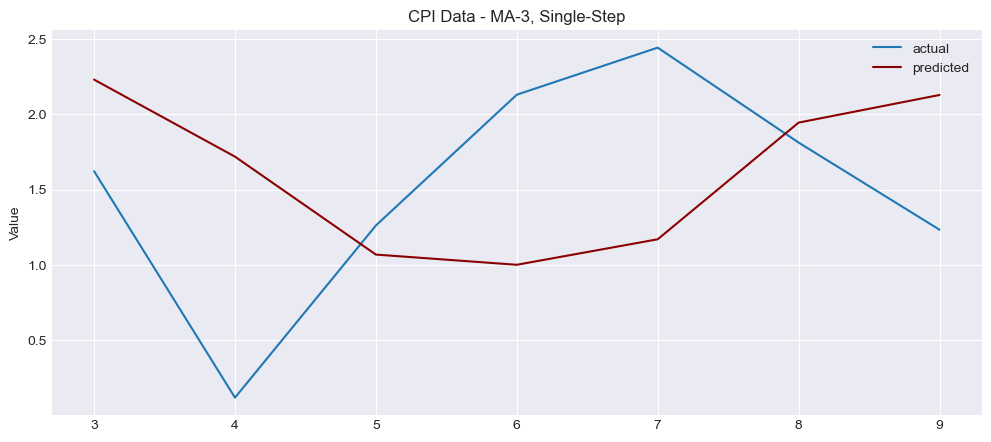

In [70]:
cpi_test_copy = pd.DataFrame(cpi_test)
cpi_test_copy['MA-3'] = cpi_test_copy[0].rolling(3).mean().shift(1)
cpi_test_copy = cpi_test_copy.dropna()
results = evaluate_forecast(cpi_test_copy[0], cpi_test_copy['MA-3'], 'CPI Data - MA-3, Single-Step')
append_results('CPI','MA-3','Single-Step', results)

#### CPI Data, Multi-Step Moving Average (MA-3)

In [72]:
cpi_train_copy = pd.DataFrame(cpi_train).copy()
cpi_train_copy['MA-3'] = cpi_train_copy[0].rolling(3).mean().shift(1)
pred = cpi_train_copy['MA-3'][len(cpi_train_copy)-1]
predictions = np.repeat(pred, len(cpi_test))
predictions

array([3.30590563, 3.30590563, 3.30590563, 3.30590563, 3.30590563,
       3.30590563, 3.30590563, 3.30590563, 3.30590563, 3.30590563])

RMSE: 1.75
MAE: 1.57


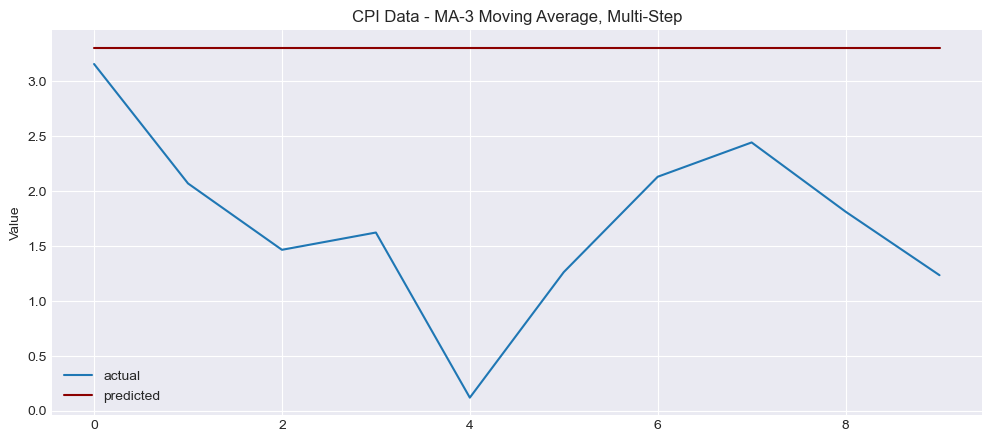

In [73]:
results = evaluate_forecast(cpi_test, predictions, 'CPI Data - MA-3 Moving Average, Multi-Step')
append_results('CPI','MA-3','Multi-Step', results)

In [74]:
results_df[results_df['Dataset'] == 'CPI'].sort_values(by='RMSE', ascending=True)

,Dataset,Model,Application,RMSE,MAE
2,CPI,Naive,MultiStep,0.78,0.59
1,CPI,Naive,Single-Step,0.95,0.84
7,CPI,MA-3,Single-Step,0.98,0.83
8,CPI,MA-3,Multi-Step,1.75,1.57
6,CPI,MA-3,Single-Step Train Set,2.36,1.69


#### On the Training Set, Seasonal Borrowing Data

In [75]:
sborrow_train_copy = pd.DataFrame(sborrow_train)
sborrow_train_copy['MA-3'] = sborrow_train_copy[0].rolling(3).mean().shift(1)
sborrow_train_copy = sborrow_train_copy.dropna()

RMSE: 28.14
MAE: 19.30


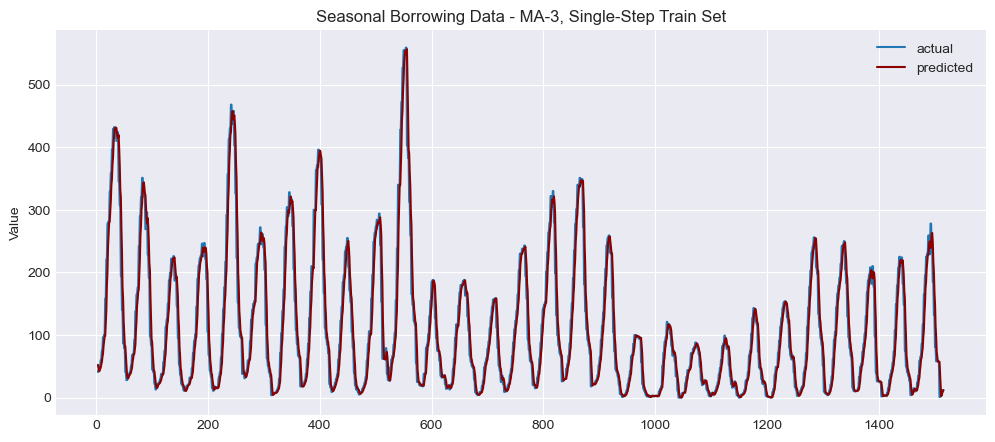

In [76]:
results = evaluate_forecast(sborrow_train_copy[0], sborrow_train_copy['MA-3'], 'Seasonal Borrowing Data - MA-3, Single-Step Train Set')
append_results('SBorrow','MA-3','Single-Step Train Set', results)

#### Seasonal Borrowing Data, Single-Step Moving Average (MA-3)

RMSE: 10.90
MAE: 7.27


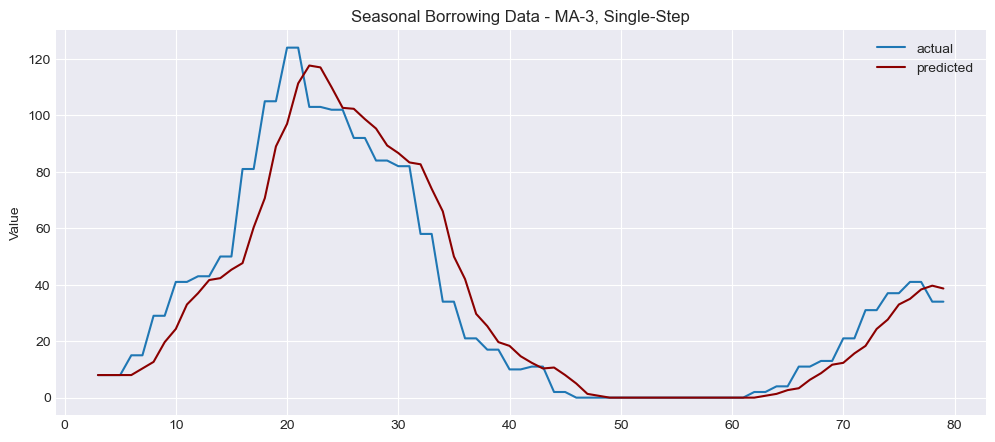

In [77]:
sborrow_test_copy = pd.DataFrame(sborrow_test)
sborrow_test_copy['MA-3'] = sborrow_test_copy[0].rolling(3).mean().shift(1)
sborrow_test_copy = sborrow_test_copy.dropna()
results = evaluate_forecast(sborrow_test_copy[0], sborrow_test_copy['MA-3'], 'Seasonal Borrowing Data - MA-3, Single-Step')
append_results('SBorrow','MA-3','Single-Step', results)

#### Seasonal Borrowing Data, Multi-Step Moving Average

In [78]:
sborrow_train_copy = pd.DataFrame(sborrow_train).copy()
sborrow_train_copy['MA-3'] = sborrow_train_copy[0].rolling(3).mean().shift(1)
pred = sborrow_train_copy['MA-3'][len(sborrow_train_copy)-1]
predictions = np.repeat(pred, len(sborrow_test))

RMSE: 41.51
MAE: 28.05


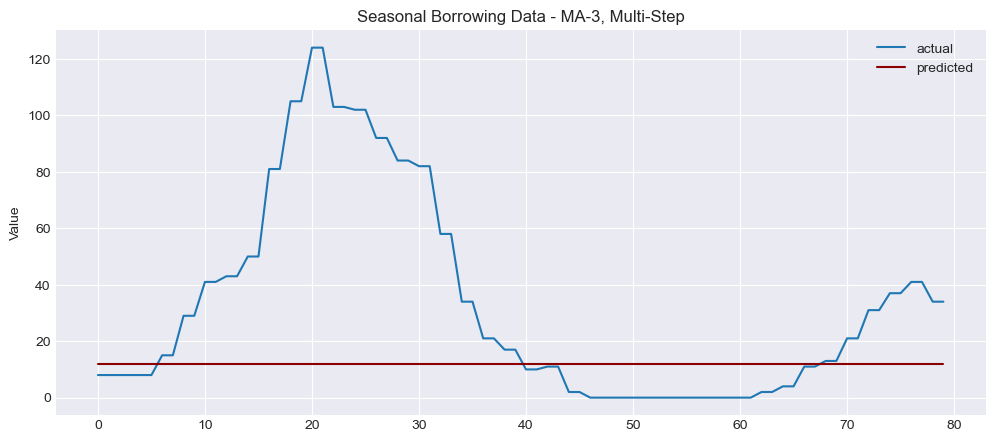

In [79]:
results = evaluate_forecast(sborrow_test, predictions, 'Seasonal Borrowing Data - MA-3, Multi-Step')
append_results('SBorrow','MA-3','Multi-Step', results)

In [80]:
results_df[results_df['Dataset'] == 'SBorrow'].sort_values(by='RMSE', ascending=True)

,Dataset,Model,Application,RMSE,MAE
3,SBorrow,Naive,Single-Step,7.72,3.68
10,SBorrow,MA-3,Single-Step,10.9,7.27
9,SBorrow,MA-3,Single-Step Train Set,28.14,19.3
4,SBorrow,Naive,Multi-Step,41.51,28.05
11,SBorrow,MA-3,Multi-Step,41.51,28.05
5,SBorrow,Naive Seasonal,Multi-Step,75.37,57.85


## Exponentially Weighted Moving Average (EWMA)

#### CPI Data, Training Set EWMA

An EWMA multiplies the current time-point’s value by an $\alpha$ value between $0$ and $1$, and the previous time-point’s value by ($1 – \alpha$), before adding the terms together.

I'll arbitrarily choose an alpha value of 0.7, but you can experiment to find which alpha seems to give the best results.

RMSE: 1.90
MAE: 1.37


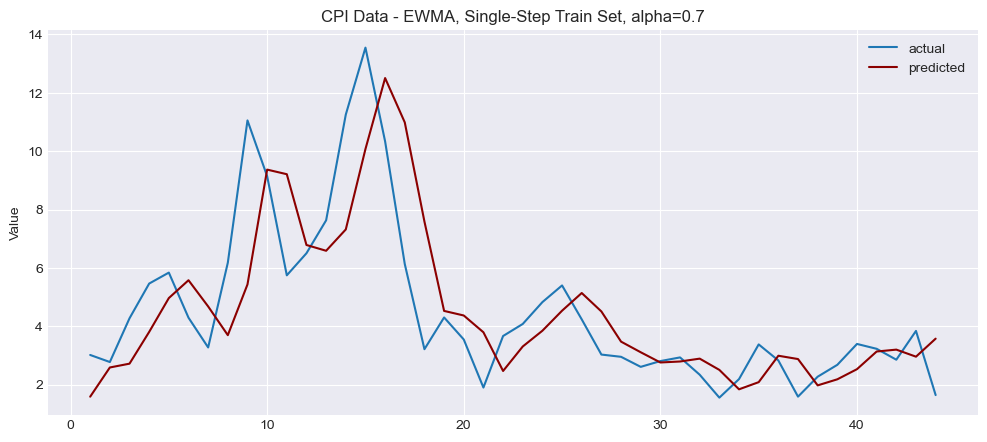

In [81]:
cpi_train_copy = pd.DataFrame(cpi_train)
cpi_train_copy['ewma'] = cpi_train_copy[0].shift(1).ewm(alpha=0.7, adjust=False).mean()
cpi_train_copy = cpi_train_copy.dropna()
results = evaluate_forecast(cpi_train_copy[0],
                            cpi_train_copy['ewma'],
                            'CPI Data - EWMA, Single-Step Train Set, alpha=0.7')
append_results('CPI', 'EWMA-0.7', 'Single-Step Train Set', results)

#### CPI Data, Single-Step EWMA-0.7

RMSE: 0.89
MAE: 0.80


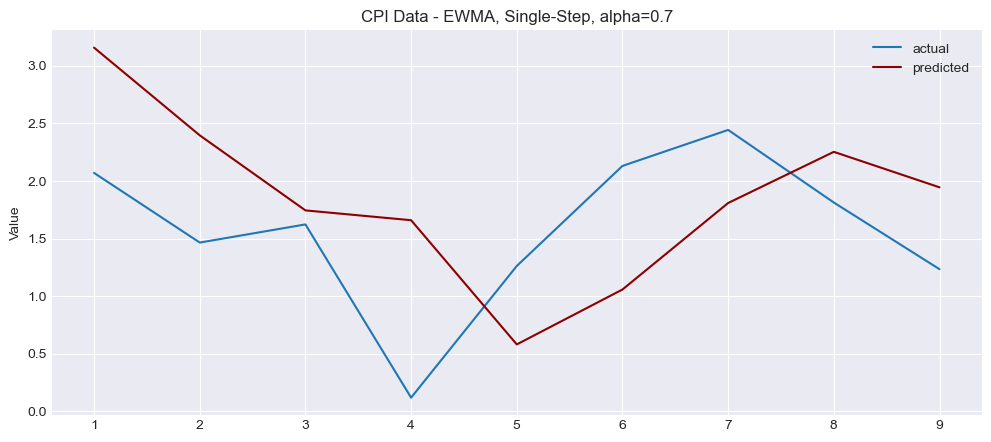

In [82]:
cpi_test_copy = pd.DataFrame(cpi_test)
cpi_test_copy['ewma'] = cpi_test_copy[0].shift(1).ewm(alpha=0.7, adjust=False).mean()
cpi_test_copy = cpi_test_copy.dropna()
results = evaluate_forecast(cpi_test_copy[0],
                            cpi_test_copy['ewma'],
                            'CPI Data - EWMA, Single-Step, alpha=0.7')
append_results('CPI', 'EWMA-0.7', 'Single-Step', results)

#### CPI Data, Multi-Step EWMA-0.7

RMSE: 1.87
MAE: 1.73


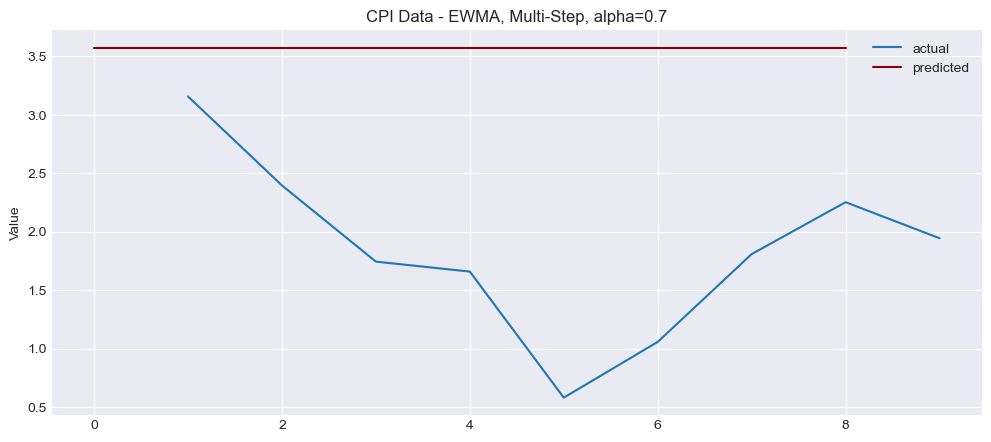

In [83]:
pred = cpi_train_copy['ewma'][len(cpi_train_copy)]
predictions = np.repeat(pred, len(cpi_test_copy))

results = evaluate_forecast(cpi_test_copy['ewma'],
                            predictions,
                            'CPI Data - EWMA, Multi-Step, alpha=0.7')
append_results('CPI', 'EWMA-0.7', 'Multi-Step', results)

In [84]:
results_df[results_df['Dataset'] == 'CPI'].sort_values(by='RMSE', ascending=True)

,Dataset,Model,Application,RMSE,MAE
2,CPI,Naive,MultiStep,0.78,0.59
13,CPI,EWMA-0.7,Single-Step,0.89,0.8
1,CPI,Naive,Single-Step,0.95,0.84
7,CPI,MA-3,Single-Step,0.98,0.83
8,CPI,MA-3,Multi-Step,1.75,1.57
14,CPI,EWMA-0.7,Multi-Step,1.87,1.73
12,CPI,EWMA-0.7,Single-Step Train Set,1.9,1.37
6,CPI,MA-3,Single-Step Train Set,2.36,1.69


#### Seasonal Data, Single-Step Training Set EWMA

RMSE: 22.32
MAE: 13.95


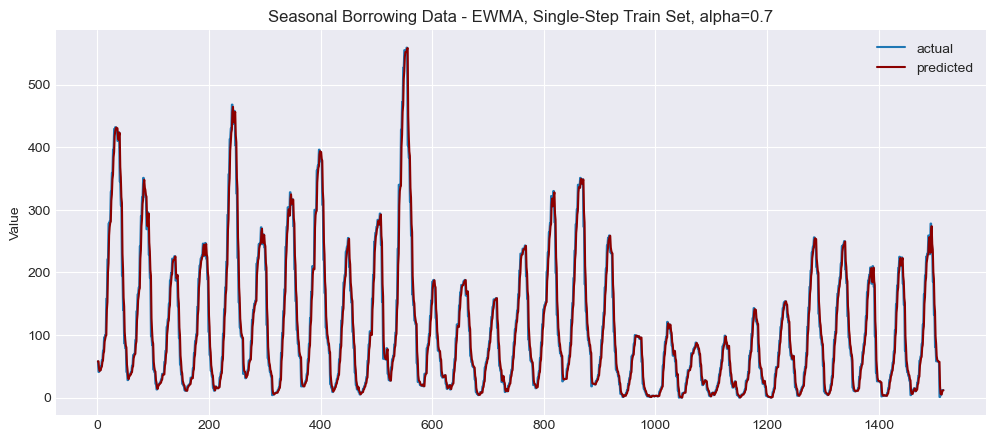

In [85]:
sborrow_train_copy = pd.DataFrame(sborrow_train)
sborrow_train_copy['ewma'] = sborrow_train_copy[0].shift(1).ewm(alpha=0.7, adjust=False).mean()
sborrow_train_copy = sborrow_train_copy.dropna()
results = evaluate_forecast(sborrow_train_copy[0],
                            sborrow_train_copy['ewma'],
                            'Seasonal Borrowing Data - EWMA, Single-Step Train Set, alpha=0.7')
append_results('SBorrow', 'EWMA-0.7', 'Single-Step Train Set', results)

#### Seasonal Borrowing Data, Single-Step EWMA-0.7

RMSE: 8.55
MAE: 5.12


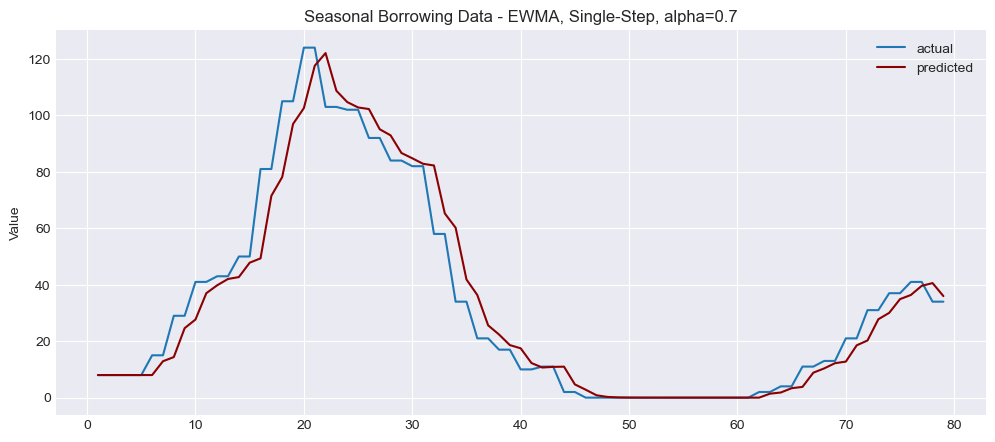

In [86]:
sborrow_test_copy = pd.DataFrame(sborrow_test)
sborrow_test_copy['ewma'] = sborrow_test_copy[0].shift(1).ewm(alpha=0.7, adjust=False).mean()
sborrow_test_copy = sborrow_test_copy.dropna()
results = evaluate_forecast(sborrow_test_copy[0],
                            sborrow_test_copy['ewma'],
                            'Seasonal Borrowing Data - EWMA, Single-Step, alpha=0.7')
append_results('SBorrow', 'EWMA-0.7', 'Single-Step', results)

#### Seasonal Borrowing Data, Multi-Step EWMA-0.7

RMSE: 41.50
MAE: 27.93


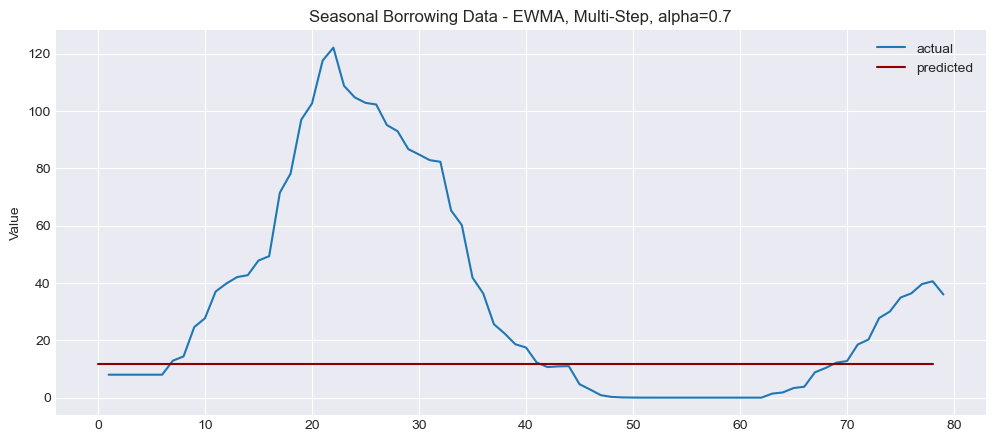

In [87]:
pred = sborrow_train_copy['ewma'][len(sborrow_train_copy)]
predictions = np.repeat(pred, len(sborrow_test_copy))

results = evaluate_forecast(sborrow_test_copy['ewma'],
                            predictions,
                            'Seasonal Borrowing Data - EWMA, Multi-Step, alpha=0.7')
append_results('SBorrow', 'EWMA-0.7', 'Multi-Step', results)

In [88]:
results_df[results_df['Dataset'] == 'SBorrow'].sort_values(by='RMSE', ascending=True)

,Dataset,Model,Application,RMSE,MAE
3,SBorrow,Naive,Single-Step,7.72,3.68
16,SBorrow,EWMA-0.7,Single-Step,8.55,5.12
10,SBorrow,MA-3,Single-Step,10.9,7.27
15,SBorrow,EWMA-0.7,Single-Step Train Set,22.32,13.95
9,SBorrow,MA-3,Single-Step Train Set,28.14,19.3
17,SBorrow,EWMA-0.7,Multi-Step,41.5,27.93
4,SBorrow,Naive,Multi-Step,41.51,28.05
11,SBorrow,MA-3,Multi-Step,41.51,28.05
5,SBorrow,Naive Seasonal,Multi-Step,75.37,57.85


The next workbook in the series is about exponential smoothing methods, and can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20II%20-%20Exponential%20Smoothing.ipynb">here</a>.